# Info

This script performs a Random Forest classification.

The following parameters can be specified:

#### TRAIN_DATA:

The dataset the random forest will be trained on. \

N22 = Northern Bavaria 2022\
N23 = Northern Bavaria 2023\
S20 = Southern Bavaria 2020\
S22 = Southern Bavaria 2022\
ALL = all of the above\

#### VAL_DATA:

The dataset the random forest will be validated on.\

N22 = Northern Bavaria 2022\
N23 = Northern Bavaria 2023\
S20 = Southern Bavaria 2020\
S22 = Southern Bavaria 2022\
ALL = all of the above\

_If VAL_DATA == TRAIN_DATA, as 5-fold Cross Validation will be used._

#### method:

This is the sampling method:\

weighted: Solely minority class ("deadwood") gets oversampled. Specify **weight** as well. Specify **total_n** (number of observations for the model) as well.\
undersampling: All the classes get undersampled to the number of the minority class.\
oversampling: All the classes get oversampled to the number of the majority class ("undisturbed"). Specify, XXXXx as well.




# 1 Import packages and functions

In [1]:
import xarray as xr
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

In [2]:
from plot_functions import *
from read_functions import *
from datahandling_functions import *
from analysis_functions import *

# 2 Read

In [3]:
chosen_bands = ["blue", "green", "red", "rededge1", "rededge3", "nir", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "contrast"] #options: "blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "nssi", "contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"
TRAIN_DATA = "ALL"
VAL_DATA = "ALL"
method = "weighted"
# if method = weight:
weight = 4
FIT = "d"

## 2.1 Read Train

In [4]:
if TRAIN_DATA == "ALL":

    df1 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")
    df2 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")
    df3 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")
    df4 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")
    df = pd.concat([df1, df2, df3, df4], axis=0, ignore_index=True)
    df = df.reset_index()
    final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass", "region", "region_class"]

if TRAIN_DATA != "ALL":

    df = open_to_pd_df(f"C:/Users/miles/OneDrive/Dokumente/ROOT/trainingdata_collection/trainingdata_withindices/{TRAIN_DATA.lower()}.tif")

    final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass"]

df.columns.name = None
df = df.loc[:, ~df.columns.duplicated()]
train_df = df[final_selection]

In [5]:
summary_table = pd.crosstab(df['region'], df["trainclass"])
print(summary_table)

trainclass      1     2       3
region                         
n22         25745  1513  342186
n23         34211   972   97471
s20          7240   354  103224
s22          3234    22  464424


## 2.2 Read Val


In [6]:
if VAL_DATA != TRAIN_DATA:

    val_df = open_to_pd_df(f"C:/Users/miles/OneDrive/Dokumente/ROOT/trainingdata_collection/trainingdata_withindices/{VAL_DATA.lower()}.tif")
    val_df = val_df.reset_index()
    val_df.columns.name = None
    val_df = val_df.loc[:, ~val_df.columns.duplicated()]
    final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass"]
    val_df = val_df[final_selection]

    forestclass_test = val_df["trainclass"]
    pred_test = val_df.drop(columns=["trainclass", "region", "regionclass"])

    forestclass_train = train_df["trainclass"]
    pred_train = train_df.drop(columns=["trainclass", "region", "regionclass"])


if VAL_DATA == TRAIN_DATA:

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    pred = df.drop(columns=['trainclass', 'region', 'region_class'])
    forestclass = df['trainclass']
    strat_col = df['region_class']

In [7]:
print("klassen im training")
print(strat_col.value_counts())

klassen im training
region_class
s22_3    464424
n22_3    342186
s20_3    103224
n23_3     97471
n23_1     34211
n22_1     25745
s20_1      7240
s22_1      3234
n22_2      1513
n23_2       972
s20_2       354
s22_2        22
Name: count, dtype: int64


# 3. TRAIN

In [ ]:
if VAL_DATA == TRAIN_DATA:

    all_accuracies = []
    all_f1s = []
    all_cms = []
    cv_predictions = np.zeros_like(forestclass)

    print(f"{'Fold':<10} | {'Accuracy':<10} | {'F1 (Weighted)':<15}")
    print("-" * 45)

    for i, (train_idx, test_idx) in enumerate(skf.split(pred, strat_col)):

        pred_train, pred_test = pred.iloc[train_idx], pred.iloc[test_idx]
        forestclass_train, forestclass_test = forestclass.iloc[train_idx], forestclass.iloc[test_idx]

        # sampling:
        train = pred_train.assign(trainclass = forestclass_train)
        train = rf_sample(train, method=method, weight = weight)
        forestclass_train = train["trainclass"]
        pred_train = train.drop("trainclass", axis=1)

        rf = randomForestClass(ntrees = 750, pred_train=pred_train, forestclass_train=forestclass_train, FIT = FIT)
        predictions = rf.predict(pred_test)
        cv_predictions[test_idx] = predictions
        acc = accuracy_score(forestclass_test, predictions)

if VAL_DATA != TRAIN_DATA:

    rf = randomForestClass(ntrees = 750, pred_train=pred_train, forestclass_train=forestclass_train)
    predictions = rf.predict(pred_test)

Fold       | Accuracy   | F1 (Weighted)  
---------------------------------------------
unbalanced scikit learn mode was used.


In [38]:
print(train["trainclass"].value_counts())
print(forestclass_test.value_counts())

trainclass
3    46267
1     3204
2      529
Name: count, dtype: int64
trainclass
3    201462
1     14085
2       572
Name: count, dtype: int64


# 4. PLOT

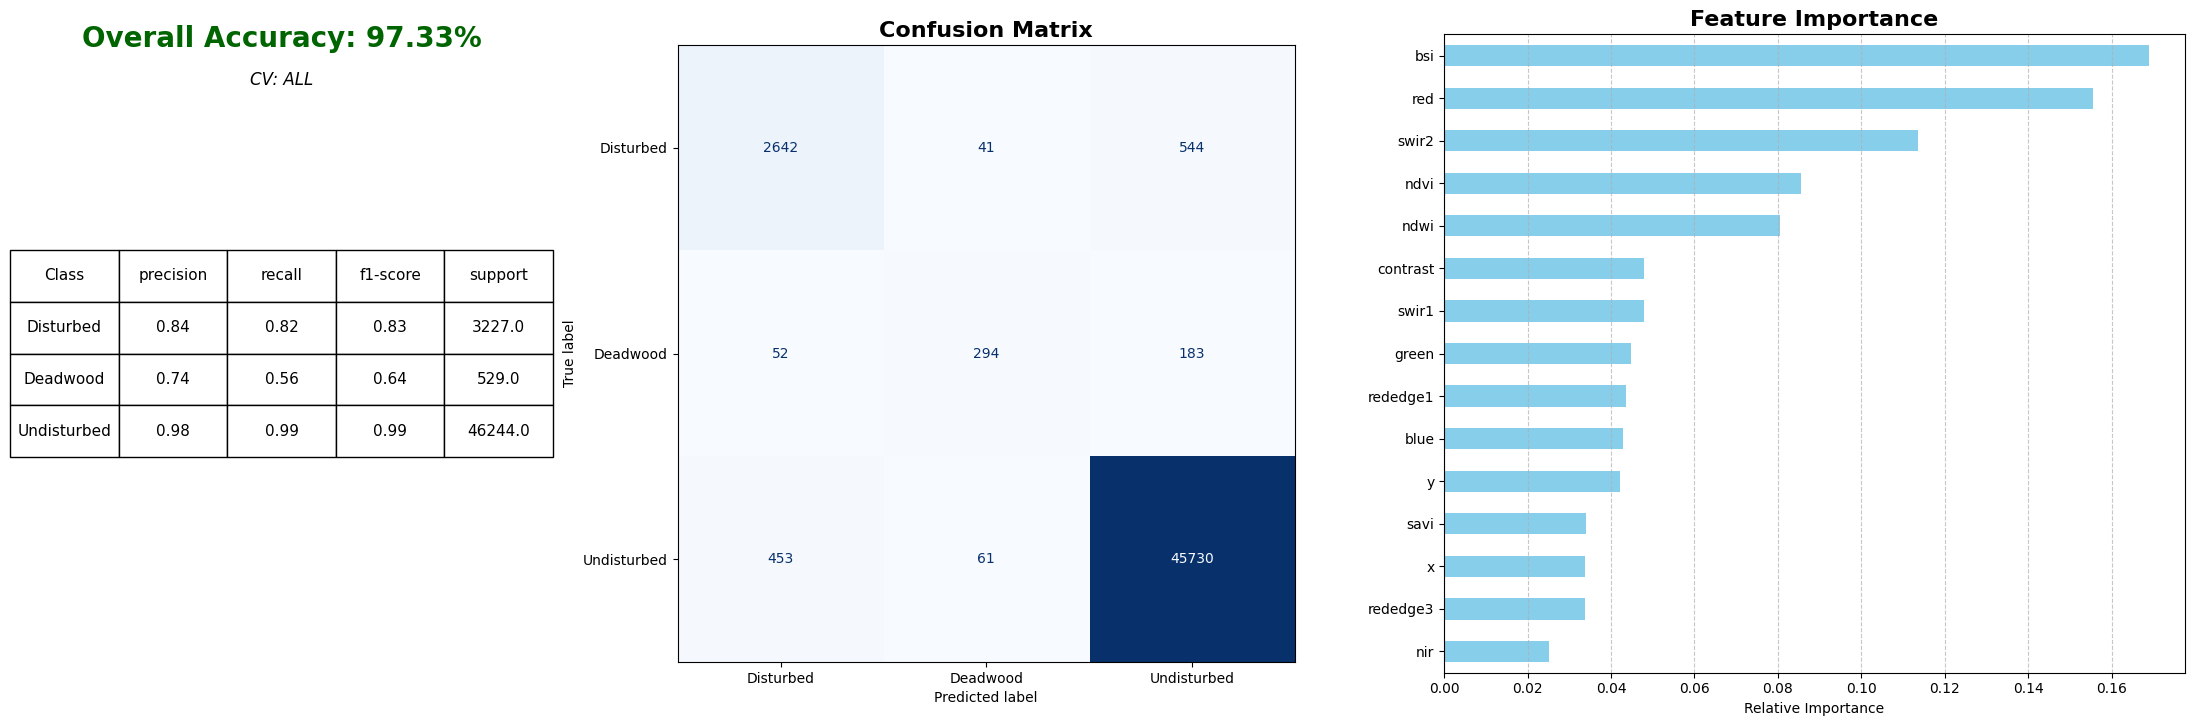

In [17]:
if VAL_DATA == TRAIN_DATA:

    importances = pd.Series(rf.feature_importances_, index=pred.columns)

    fig = plot_cross_model_results(
        y_true=forestclass,        # <--- FIX: Use the full label set, not just the last fold
        y_pred=cv_predictions,     # <--- This now matches the length of 'forestclass'
        feature_importances=importances,
        train_mode=TRAIN_DATA,
        val_mode=VAL_DATA,
        class_names=['Disturbed', 'Deadwood', 'Undisturbed']
    )

    plt.show()

else:

    fig = plot_model_results(
        y_true=forestclass_test,
        y_pred=predictions,
        rf_model=rf,
        feature_names=chosen_bands,
        train_mode=TRAIN_DATA,
        val_mode=VAL_DATA,)
    plt.show()

In [16]:
print(all_f1s[1])

IndexError: list index out of range